## NMD Models: Wealth Allocation Model

This notebook shows how to develop the wealth allocation model.

### Input from other components
| Input | From | Use for |
|---|---|---|
| `core_balance`, `wal_years` | Notebook 05 Runoff proflie | Setting scale |
| `caterpillar yield, duration` | Notebook 08 Caterpillar hedging | Yield and Duration |

### Core idea
Allocate core balance across different investment strategies to maximize Net Interest Income (NII) under IRRBB constraints.

### 3 Strategies
| Strategy | Description | Duration | Yield |
|---|---|---|---|
| Caterpillar (Fixed) | Rolling tranche | ~3Y | 5Y Rate |
| Floating Rate | Invest overnight (6M) | ~0.50Y | 6M Rate |
| Liquidity Buffer | Minimum hold at 15% | ~0.25Y | 3M Rate |

## Objective
```
Maximise NII = (w_cat × y_cat + w_float × y_float + w_liq × y_liq) × core_balance

Subject to w_cat + w_float + w_liq  = 1
ΔEVE = Σ(w_i × dur_i) × core × shock  ≤ EVE_LIMIT
w_liq ≥ MIN_LIQ
w_i ≥ 0
```

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.wealth_allocation import optimise_allocation, allocation_sensitivity, compute_lcr, compute_nsfr
from src.plot_function import plot_allocation_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
market_rate  = df["market_rate"]
deposit_rate = df["deposit_rate"]
balance = df["balance"]

# Show
df[["market_rate", "deposit_rate", "balance"]].describe().round(4)

,market_rate,deposit_rate,balance
count,150.000,150.000,150.000
mean,0.049,0.009,5185.951
std,0.007,0.002,335.315
min,0.028,0.004,4523.784
25%,0.043,0.008,4880.310
50%,0.048,0.009,5256.091
75%,0.054,0.010,5414.796
max,0.064,0.013,6083.954


In [4]:
# Import related models
# Import yield curve
with open("../model/yield_curve.pkl", "rb") as file:
    yield_curve = pickle.load(file)

In [5]:
# Get Strategy Yields
yc = yield_curve.iloc[-1]
yields = {
    "cat": float(yc["5Y"]),
    "float": float(yc["6M"]),
    "liq": float(yc["3M"]),
    "r0": float(df["market_rate"].values[-1]),
    "yield_curve": yc
}

# Show
print("=" * 60)
print(f"Current yield curve:")
for lbl, val in yields["yield_curve"].items():
    print(f"{lbl:<{5}}: {val:.2%}")
print("=" * 60)
print(f"Strategy yields")
print(f"{"Caterpillar (5Y)":<{18}}: {yields['cat']:.2%}")
print(f"{"Floating (6M)":<{18}}: {yields['float']:.2%}")
print(f"{"Liquidity (3M)":<{18}}: {yields['liq']:.2%}")
print(f"{"Deposit rate":<{18}}: {float(deposit_rate.iloc[-1]):.2%}")
print(f"{"Spread":<{18}}: {yields['cat'] - float(deposit_rate.iloc[-1]):.2%} (Caterpillar - Deposit)")
print("=" * 60)

Current yield curve:
3M   : 2.44%
6M   : 3.15%
1Y   : 3.60%
2Y   : 3.95%
3Y   : 4.52%
5Y   : 4.85%
10Y  : 5.34%
Strategy yields
Caterpillar (5Y)  : 4.85%
Floating (6M)     : 3.15%
Liquidity (3M)    : 2.44%
Deposit rate      : 0.73%
Spread            : 4.12% (Caterpillar - Deposit)


In [6]:
# Get upstream parameters
CORE_BALANCE =  3850.14 #MB
WAL_LIABILITY = 3.0 #Years

# Best caterpillar: tenor: 5 Years, n: 5 Tranches
DUR_CAT = 3.0 #Average duration = 5 − (5 − 1)/2 = 3
DUR_FLOAT = 0.5 #Floating = overnight (3M)
DUR_LIQ = 0.25 #Liquidity buffer (3M)

RATE_SHOCK = 0.02 #+200bps
EVE_LIMIT_PCT = 0.06 #Max ΔEVE = 6% of core
MIN_LIQ_PCT = 0.15 #Minimum 15% liquidity buffer

# Show
print("=" * 60)
print(f"{"Core Balance":<{20}}: {CORE_BALANCE:,.2f} MB")
print(f"{"WAL Liability":<{20}}: {WAL_LIABILITY:.0f} years")
print(f"{"EVE Limit":<{20}}: {EVE_LIMIT_PCT:.2%} of core = {EVE_LIMIT_PCT * CORE_BALANCE:,.2f} MB")
print(f"{"Min Liquidity":<{20}}: {MIN_LIQ_PCT:.2%}")
print("=" * 60)

Core Balance        : 3,850.14 MB
WAL Liability       : 3 years
EVE Limit           : 6.00% of core = 231.01 MB
Min Liquidity       : 15.00%


In [ ]:
# Optimise Allocation
alloc_result = optimise_allocation(
    core_balance = CORE_BALANCE,
    yields = yields, 
    dur_cat = DUR_CAT,
    dur_float = DUR_FLOAT,
    dur_liq = DUR_LIQ,
    rate_shock = RATE_SHOCK,
    eve_limit_pct = EVE_LIMIT_PCT,
    min_liq_pct = MIN_LIQ_PCT,
    n_starts = 10
)

w = alloc_result["weights"]
nb = alloc_result["notional_mb"]

# Result
print("=" * 60)
print(f"{"Converged":<{20}}: {alloc_result['converged']}")
print("=" * 60)
print("Optimal allocation")
print(f"{"Caterpillar":<{20}}: {w['cat']:.2%}  {nb['cat']:,.2f} MB (Yield: {yields['cat']:.2%})")
print(f"{"Floating":<{20}}: {w['float']:.2%}  {nb['float']:,.2f} MB (Yield: {yields['float']:.2%})")
print(f"{"Liquidity buffer":<{20}}: {w['liq']:.2%}  {nb['liq']:,.2f} MB (Yield: {yields['liq']:.2%})")
print("=" * 60)
print(f"{"NII Annual":<{20}}: {alloc_result['nii_annual']:,.2f} MB")
print(f"{"ΔEVE (Approx)":<{20}}: {alloc_result['delta_eve']:,.2f} MB")
print(f"{"EVE Limit":<{20}}: {alloc_result['eve_limit']:,.2f} MB")
print(f"{"EVE Constraint":<{20}}: {'✓' if alloc_result['delta_eve'] <= alloc_result['eve_limit'] else '✗'}")
print(f"{"Liquidity Constraint":<{20}}: {'✓' if w['liq'] >= MIN_LIQ_PCT - 0.001 else '✗'}")
print("=" * 60)

Converged           : True
Optimal allocation
Caterpillar         : 85.00%  3,272.6 MB (Yield: 4.85%)
Floating            : 0.00%  0.0 MB (Yield: 3.15%)
Liquidity buffer    : 15.00%  577.5 MB (Yield: 2.44%)
NII Annual          : 172.82 MB
ΔEVE (Approx)       : 199.24 MB
EVE Limit           : 231.01 MB
EVE Constraint      : ✓
Liquidity Constraint: ✓


In [8]:
# Sensitivity to EVE Limit
sensitivity_table = allocation_sensitivity(
    core_balance = CORE_BALANCE,
    yields = yields,
    dur_cat = DUR_CAT,
    dur_float = DUR_FLOAT,
    dur_liq = DUR_LIQ,
    rate_shock = RATE_SHOCK,
    min_liq_pct = MIN_LIQ_PCT,
    eve_limit_range = [0.03, 0.04, 0.05, 0.06, 0.10]
)

# Result
print("Allocation sensitivity to EVE limit")
sensitivity_table

Allocation sensitivity to EVE limit


,eve_limit_mb,w_cat,w_float,w_liq,nii_annual_mb,delta_eve_mb,converged
eve_limit_pct,,,,,,,
3%,115.500,41.500,43.500,15.000,144.340,115.500,True
4%,154.000,61.500,23.500,15.000,157.430,154.010,True
5%,192.500,81.500,3.500,15.000,170.530,192.510,True
6%,231.000,85.000,0.000,15.000,172.820,199.240,True
10%,385.000,85.000,0.000,15.000,172.820,199.240,True


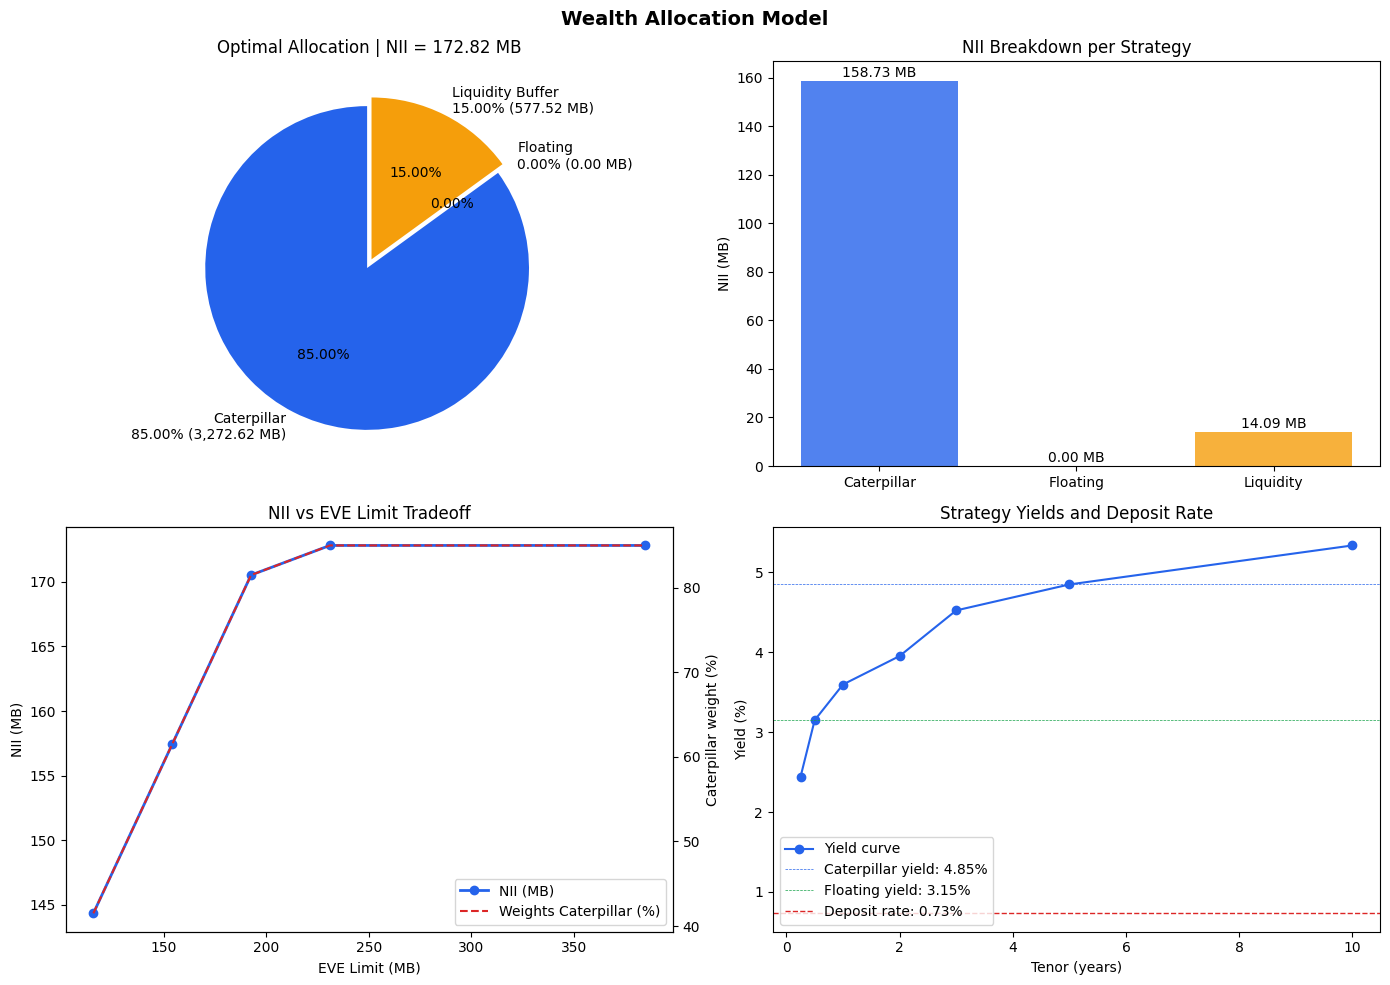

In [9]:
# Plot visualise results
plot_allocation_results(
    alloc_result = alloc_result,
    sensitivity_table = sensitivity_table,
    yields = yields,
    deposit_rate = deposit_rate
)

In [ ]:
# LCR / NSFR Integration
NON_CORE_BALANCE = float(balance.iloc[-1]) - CORE_BALANCE  #Reproduce

# LCR
lcr_result = compute_lcr(
    core_balance = CORE_BALANCE,
    non_core_balance = NON_CORE_BALANCE,
    alloc_result = alloc_result
)

# NSFR
nsfr_result = compute_nsfr(
    core_balance = CORE_BALANCE,
    non_core_balance = NON_CORE_BALANCE,
    alloc_result = alloc_result
)

# Result
print("=" * 60)
print(f"LCR Result")
print(f"{"HQLA":<{20}}: {lcr_result['hqla']:,.1f} MB")
print(f"{"Total outflow (30d)":<{20}}: {lcr_result['total_outflow']:,.1f} MB")
print(f"{"LCR":<{20}}: {lcr_result['lcr_pct']:.1f}%  {'✓ PASS' if lcr_result['lcr_pass'] else '✗ FAIL'}")
print(f"{"Dynamic Min LIQ":<{20}}: {lcr_result['min_liq_dynamic']:.2%} (Static = {MIN_LIQ_PCT:.0%})")
print("=" * 60)
print(f"NSFR Results")
print(f"{"ASF total":<{20}}: {nsfr_result['asf_total']:,.2f} MB")
print(f"{"RSF total":<{20}}: {nsfr_result['rsf_total']:,.2f} MB")
print(f"{"NSFR":<{20}}: {nsfr_result['nsfr_pct']:.2f}%  {'✓ PASS' if nsfr_result['nsfr_pass'] else '✗ FAIL'}")
print("=" * 60)

LCR Result
HQLA                : 577.5 MB
Total outflow (30d) : 538.0 MB
LCR                 : 107.3%  ✓ PASS
Dynamic Min LIQ     : 13.97% (Static = 15%)
NSFR Results
ASF total           : 4,204.26 MB
RSF total           : 2,810.60 MB
NSFR                : 149.59%  ✓ PASS
